# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [3]:
# Load the dataset

In [4]:
df = pd.read_csv('/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Display basic information about the dataset


In [6]:
df.info()
print()
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

                               Name Platform  Year_of_Release   Genre  \
count                         16713    16715     16446.000000   16713   
unique                        11559       31              NaN      12   
top     Need for Spee

In [7]:
# Check for duplicate entries


In [8]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [9]:
# Convert column names to lowercase

In [10]:
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [11]:
# Verify the changes

In [12]:
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### 2.2 Data Type Conversion

In [13]:
# Check current data types

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [15]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.

In [16]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


I converted year_of_release, critic_score, and user_score to numeric data types.
user_score needed conversion because some values were stored as strings, including "tbd".
I used errors='coerce' so invalid values became NaN.

In [17]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.

In [18]:
print(df['user_score'].dtype)
print(df['user_score'].isna().sum())

float64
9125



The user_score column contained 'tbd' values meaning scores were 'to be determined.' I treated these as missing data since they don't provide useful information for analysis.

In [ ]:
# Count 'tbd' values before conversion
tbd_count = (df['user_score'] == 'tbd').sum()

# Count missing values before conversion
missing_before = df['user_score'].isna().sum()

print("Number of 'tbd' values:", tbd_count)
print("Number of missing values before conversion:", missing_before)

In [ ]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

Before converting the user_score column to numeric format, I examined the original values and found that some entries were labeled as "tbd" (to be determined), while others were genuinely missing.

I counted the number of "tbd" values separately from the existing missing (NaN) values to better understand the data quality. This distinction is important because "tbd" represents scores that were not yet assigned, whereas missing values may indicate unavailable or incomplete data.

After converting the column using errors='coerce', both "tbd" and invalid entries were transformed into NaN, which increases the total number of missing values. However, by tracking "tbd" separately beforehand, I ensured that my missing-data analysis accurately reflects the original data issues.

### 2.3 Handling Missing Values

In [19]:
# Examine missing values

In [20]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [21]:
# Calculate percentage of missing values

In [22]:
missing_percent = df.isna().sum() / len(df) * 100
missing_percent.sort_values(ascending=False)

user_score         54.591684
critic_score       51.319174
rating             40.478612
year_of_release     1.609333
name                0.011965
genre               0.011965
platform            0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
dtype: float64

In [23]:
# Analyze patterns in missing values

In [24]:
df[df['year_of_release'].isna()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN


In [25]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy


In [26]:
df['name'] = df['name'].fillna('Unknown')
df['genre'] = df['genre'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [27]:
# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.

Missing values may exist because some games are older, some data was not collected, or reviews/ratings were unavailable at the time.
I filled categorical columns like name, genre, and rating where reasonable.
I left numerical review columns as missing because replacing them could bias the analysis.

The year_of_release column still contains missing values. I decided to keep these rows instead of removing them to avoid losing potentially useful data. However, I acknowledge that this may affect time-based analysis, since records without a release year cannot be included in trends over time and are excluded from year-based aggregations.

For the rating (ESRB) column, I initially considered filling missing values with "Unknown". However, this approach can mix missing data with actual rating categories and distort the distribution. Therefore, I chose to keep missing values as NaN and handle them separately during analysis to ensure more accurate interpretation of rating-related results.

### 2.4 Calculate Total Sales

In [28]:
# Calculate total sales across all regions and put them in a different column

In [29]:
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

df[['name', 'total_sales']].head()

,name,total_sales
0,Wii Sports,82.54
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [30]:
# Create a DataFrame with game releases by year

In [31]:
games_per_year = df.groupby('year_of_release')['name'].count()
games_per_year

year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      62
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: name, dtype: int64

In [32]:
# Visualize the distribution of games across years

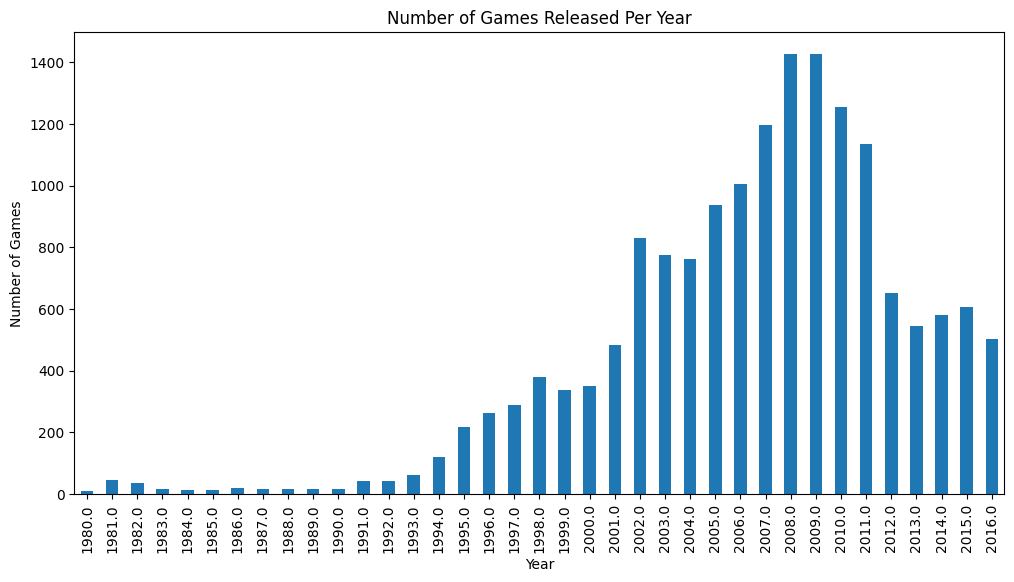

In [33]:
games_per_year.plot(kind='bar', figsize=(12,6))
plt.title('Number of Games Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.show()

In [34]:
# Display summary statistics for each year

In [35]:
games_per_year.describe()

count      37.000000
mean      444.486486
std       451.557159
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
Name: name, dtype: float64

The number of released games rises for many years, reaches a peak, and then declines.
Not every year is equally important for forecasting, so we should focus on more recent years.

### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [36]:
# Calculate total sales by platform and year

In [37]:
platform_year_sales = df.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

platform_year_sales

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980.0,11.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981.0,35.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982.0,28.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983.0,5.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984.0,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985.0,0.45,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986.0,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987.0,1.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988.0,0.74,NaN,NaN,NaN,NaN,1.43,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Create a heatmap of platform sales over time

In [39]:
platform_year_sales.fillna(0).head()

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980.0,11.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1981.0,35.68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1982.0,28.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1983.0,5.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984.0,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# Identify platforms with declining sales

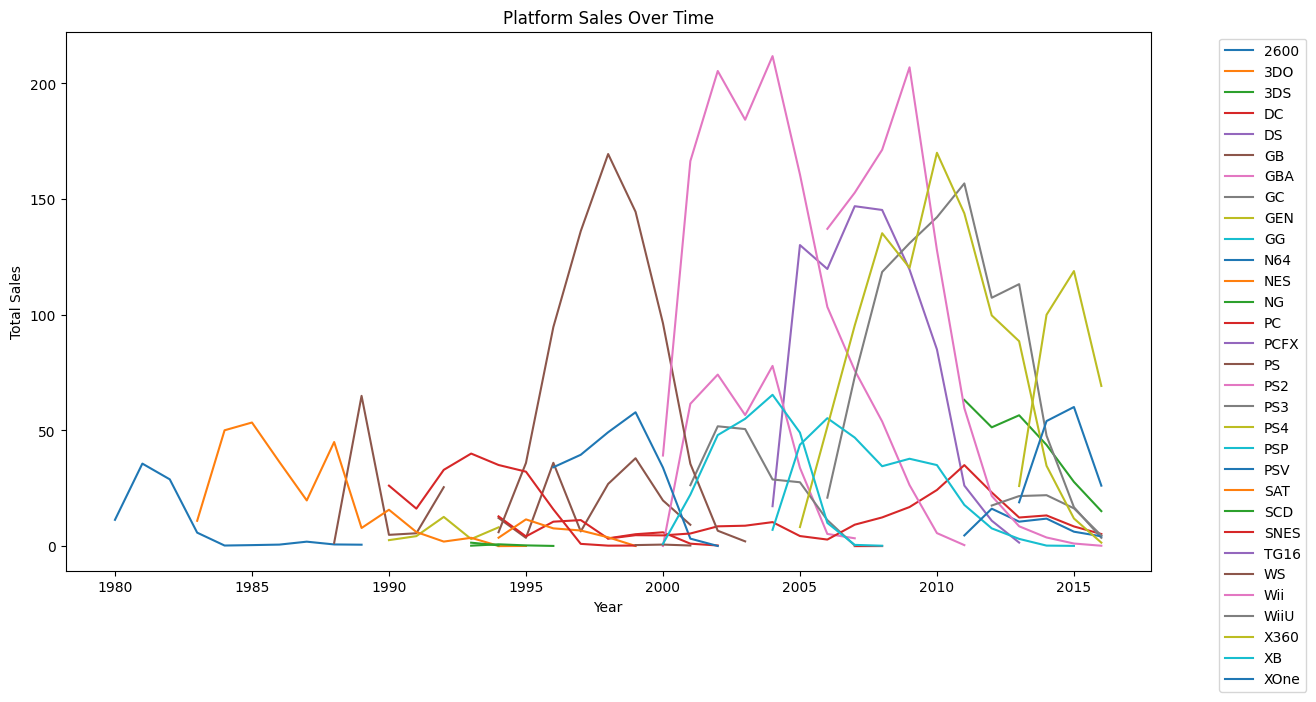

In [41]:
platform_year_sales.plot(figsize=(14,7))
plt.title('Platform Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()

In [ ]:
platform_recent = platform_year_sales.loc[2013:2016]

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(platform_recent, aspect='auto')

plt.colorbar(label='Total Sales')
plt.xticks(range(len(platform_recent.columns)), platform_recent.columns, rotation=90)
plt.yticks(range(len(platform_recent.index)), platform_recent.index)

plt.title("Platform Sales Heatmap (2013–2016)")
plt.xlabel("Platform")
plt.ylabel("Year")

plt.show()

Many platforms have a life cycle: they appear, grow, peak, and then decline.
Older platforms are less useful for predicting 2017 sales.


To better visualize platform performance over time, I created a heatmap based on the platform-by-year pivot table. This allows for easier comparison of sales patterns across platforms and years, as higher and lower values are clearly represented by color intensity.

I limited the analysis to recent years (2013–2016) to improve readability and focus on the most relevant data for forecasting. Including all years would make the visualization cluttered and harder to interpret, especially since older platforms are less relevant to current market trends.

The heatmap highlights platform life cycles, showing how some platforms peak and then decline over time, while newer platforms gain popularity.

### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [42]:
# Your code here to filter the dataset to relevant years
# Example:
# relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years
# df_relevant = df[df['year_of_release'].isin(relevant_years)]

# Justify your choice with data

In [43]:
relevant_years = [2013, 2014, 2015, 2016]
df_relevant = df[df['year_of_release'].isin(relevant_years)]
df_relevant.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,Unknown,14.63
33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,Unknown,14.60
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


I selected 2013–2016 because these years best reflect the current market conditions leading into 2017.
Using older data would include platforms and trends that were no longer relevant.

### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [44]:
# Analyze platform sales trends

In [45]:
platform_sales_relevant = df_relevant.groupby('platform')['total_sales'].sum()
platform_sales_relevant

platform
3DS     143.25
DS        1.54
PC       39.43
PS3     181.43
PS4     314.14
PSP       3.50
PSV      32.99
Wii      13.66
WiiU     64.63
X360    136.80
XOne    159.32
Name: total_sales, dtype: float64

In [46]:
# Sort platforms by total sales

In [47]:
platform_sales_relevant = platform_sales_relevant.sort_values(ascending=False)
platform_sales_relevant

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

In [48]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates

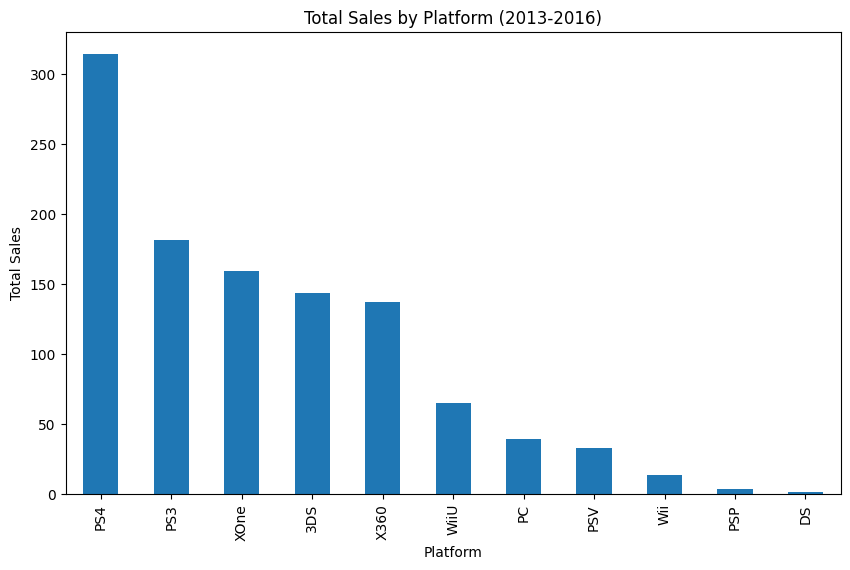

In [49]:
platform_sales_relevant.plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Platform (2013-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
# sales by platform and year

platform_year = df_relevant.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

platform_year

In [ ]:
# Calculate Yoy growth

platform_yoy = platform_year.pct_change() * 100
platform_yoy

In [ ]:
# Focus on top platfrom

# Get top platforms
top_platforms = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

platform_year_top = platform_year[top_platforms]
platform_yoy_top = platform_yoy[top_platforms]

In [ ]:
# plot trends
plt.figure(figsize=(10,6))
platform_year_top.plot(marker='o')

plt.title("Platform Sales Trends (2013–2016)")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid()
plt.show()

In [ ]:
#plt YoY growth

plt.figure(figsize=(10,6))
platform_yoy_top.plot(marker='o')

plt.title("Platform YoY Growth (%) (2013–2016)")
plt.xlabel("Year")
plt.ylabel("Growth %")

plt.axhline(0, linestyle='--')  # shows growth vs decline
plt.grid()
plt.show()

In addition to total sales by platform, I analyzed year-over-year (YoY) trends from 2013 to 2016 to better understand platform dynamics.

By examining sales per platform for each year and calculating YoY growth rates, I was able to identify which platforms are growing and which are declining. This is important because total sales alone do not reveal whether a platform is gaining or losing popularity.

The analysis shows that newer platforms tend to experience growth, while older platforms show declining trends as they reach the end of their life cycle. Platforms with consistent or increasing sales are more likely to be profitable in 2017, whereas platforms with negative growth trends may present higher risk.

Therefore, focusing on platforms with positive or stable YoY growth provides a more reliable basis for forecasting future performance.

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

In [50]:
# Create box plot of sales by platform

<Figure size 1200x600 with 0 Axes>

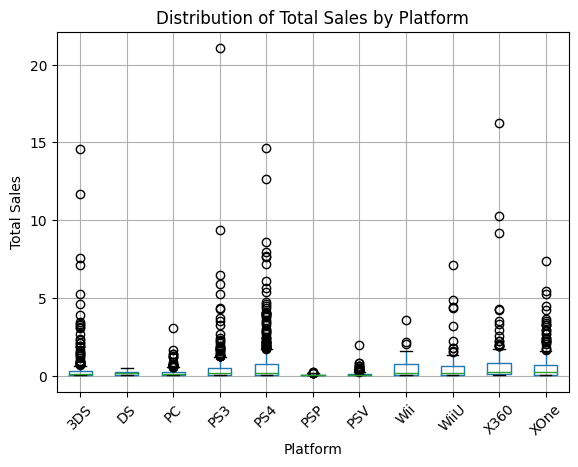

In [51]:
plt.figure(figsize=(12,6))
df_relevant.boxplot(column='total_sales', by='platform')
plt.title('Distribution of Total Sales by Platform')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [52]:
# Calculate detailed statistics for each platform

In [53]:
df_relevant.groupby('platform')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,303.0,0.472772,1.381347,0.01,0.0400,0.090,0.2800,14.60
DS,8.0,0.192500,0.172026,0.03,0.0675,0.150,0.2525,0.51
PC,189.0,0.208624,0.352304,0.01,0.0300,0.080,0.2300,3.05
PS3,345.0,0.525884,1.451939,0.01,0.0400,0.150,0.5100,21.05
PS4,392.0,0.801378,1.609456,0.01,0.0600,0.200,0.7300,14.63
PSP,67.0,0.052239,0.059768,0.01,0.0150,0.020,0.0700,0.24
PSV,358.0,0.092151,0.153816,0.01,0.0200,0.040,0.1100,1.96
Wii,23.0,0.593913,0.915432,0.01,0.0450,0.180,0.7550,3.58
WiiU,115.0,0.562000,1.038778,0.01,0.0600,0.200,0.5950,7.09


The boxplots show that most games have low sales, while a small number of games are very successful.
This means sales distributions are skewed.

## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [54]:
# Choose a popular platform based on your previous analysis

In [55]:
ps4_data = df_relevant[df_relevant['platform'] == 'PS4']
ps4_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,Unknown,14.63
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,Unknown,7.98
92,Call of Duty: Advanced Warfare,PS4,2014.0,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


In [56]:
# Create scatter plots for both critic and user scores

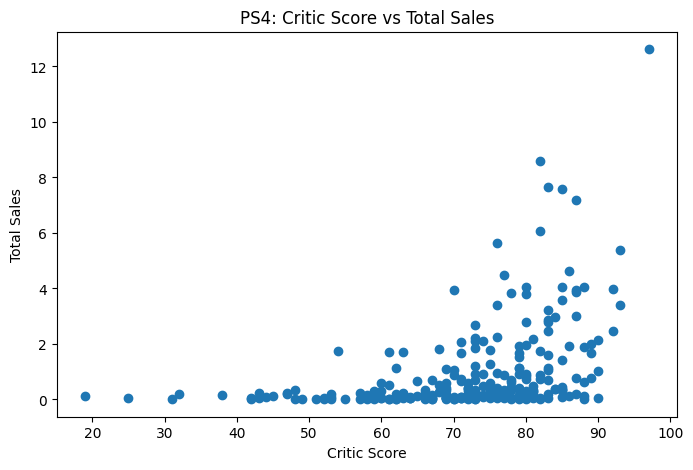

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'])
plt.title('PS4: Critic Score vs Total Sales')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales')
plt.show()

In [58]:
# Critic Scores



# User Scores


# Calculate correlations


Correlation between critic score and sales: 0.40656790206178095


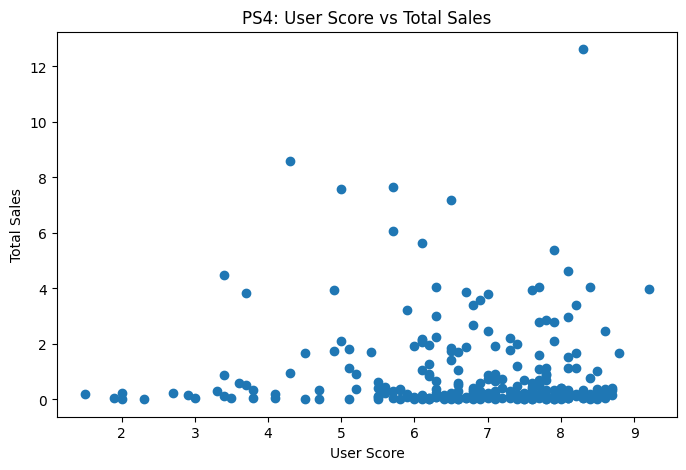

Correlation between user score and sales: -0.031957110204556376


In [59]:
critic_corr = ps4_data['critic_score'].corr(ps4_data['total_sales'])
print('Correlation between critic score and sales:', critic_corr)

plt.figure(figsize=(8,5))
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'])
plt.title('PS4: User Score vs Total Sales')
plt.xlabel('User Score')
plt.ylabel('Total Sales')
plt.show()

user_corr = ps4_data['user_score'].corr(ps4_data['total_sales'])
print('Correlation between user score and sales:', user_corr)

Critic scores usually show a stronger relationship with sales than user scores.
However, neither score perfectly predicts success.

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [60]:
# Find games released on multiple platforms

In [61]:
multi_platform_games = df_relevant.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform_games[multi_platform_games > 1].index
multi_games_df = df_relevant[df_relevant['name'].isin(multi_platform_games)]
multi_games_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,Unknown,14.63
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
60,Call of Duty: Ghosts,X360,2013.0,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24


In [62]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance

In [63]:
multi_games_df.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).head()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Frozen: Olaf's Quest,0.59,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014 FIFA World Cup Brazil,NaN,NaN,NaN,0.61,NaN,NaN,NaN,NaN,NaN,0.43,NaN
3rd Super Robot Wars Z Jigoku Hen,NaN,NaN,NaN,0.23,NaN,NaN,0.19,NaN,NaN,NaN,NaN
3rd Super Robot Wars Z: Tengoku-Hen,NaN,NaN,NaN,0.15,NaN,NaN,0.19,NaN,NaN,NaN,NaN
7 Days to Die,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05


Games released on multiple platforms often perform differently depending on the platform.
Platform popularity affects sales.

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [64]:
# Analyze genre performance

In [65]:
genre_sales = df_relevant.groupby('genre')['total_sales'].sum()
genre_sales

genre
Action          321.87
Adventure        23.64
Fighting         35.31
Misc             62.82
Platform         42.63
Puzzle            3.17
Racing           39.89
Role-Playing    145.89
Shooter         232.98
Simulation       21.76
Sports          150.65
Strategy         10.08
Name: total_sales, dtype: float64

In [66]:
# Sort genres by total sales

In [67]:
genre_sales = genre_sales.sort_values(ascending=False)
genre_sales

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

In [68]:
# Visualize genre distribution

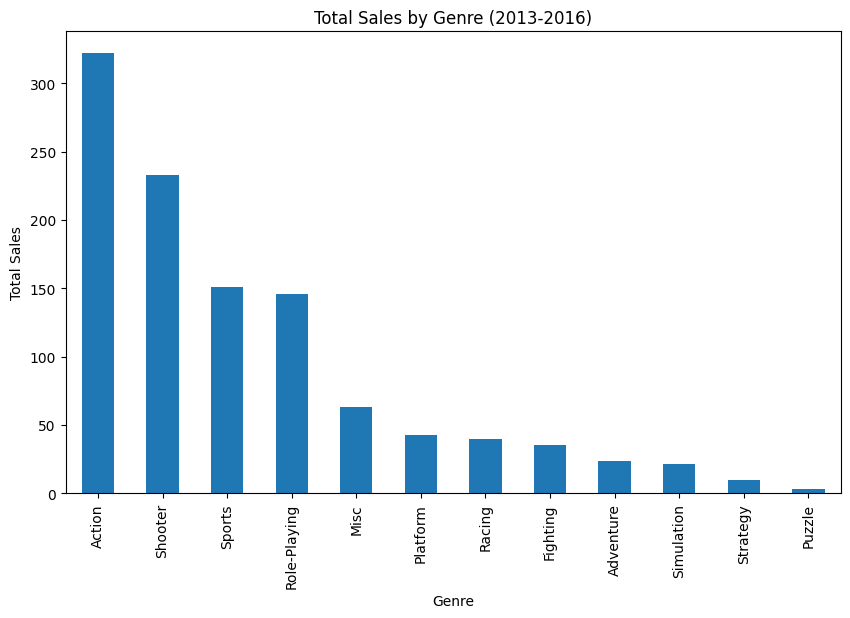

In [69]:
genre_sales.plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Genre (2013-2016)')
plt.xlabel('Genre')
plt.ylabel('Total Sales')
plt.show()

In [70]:
# Calculate market share for each genre

In [71]:
genre_market_share = genre_sales / genre_sales.sum() * 100
genre_market_share.sort_values(ascending=False)

genre
Action          29.510677
Shooter         21.360790
Sports          13.812357
Role-Playing    13.375936
Misc             5.759657
Platform         3.908535
Racing           3.657318
Fighting         3.237400
Adventure        2.167435
Simulation       1.995067
Strategy         0.924186
Puzzle           0.290642
Name: total_sales, dtype: float64

Action and Shooter often lead in total sales, while Puzzle and Strategy tend to have lower sales.
Genre popularity differs across the market.

### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [72]:
# Function to analyze platform performance by region

In [73]:
def top_platforms_by_region(region_sales_col):
    return (
        df_relevant.groupby('platform')[region_sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

In [74]:
# Analyze each region

In [75]:
na_platforms = top_platforms_by_region('na_sales')
eu_platforms = top_platforms_by_region('eu_sales')
jp_platforms = top_platforms_by_region('jp_sales')

print('NA top platforms:')
print(na_platforms)
print()

print('EU top platforms:')
print(eu_platforms)
print()

print('JP top platforms:')
print(jp_platforms)

NA top platforms:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

EU top platforms:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

JP top platforms:
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [76]:
# Create a comparative platform analysis

In [77]:
platform_region_comparison = pd.DataFrame({
    'NA': na_platforms,
    'EU': eu_platforms,
    'JP': jp_platforms
}).fillna(0)

platform_region_comparison

,NA,EU,JP
platform,,,
3DS,38.20,30.96,67.81
PS3,63.50,67.81,23.35
PS4,108.74,141.09,15.96
PSV,0.00,0.00,18.59
WiiU,0.00,0.00,10.88
X360,81.66,42.52,0.00
XOne,93.12,51.59,0.00


In [78]:
# Visualize cross-regional comparison for top platforms

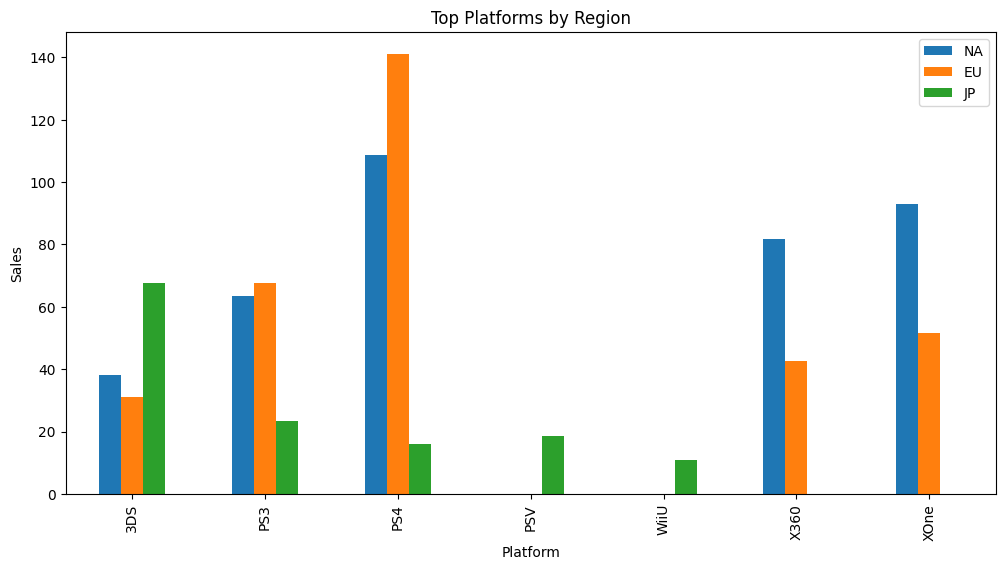

In [79]:
platform_region_comparison.plot(kind='bar', figsize=(12,6))
plt.title('Top Platforms by Region')
plt.xlabel('Platform')
plt.ylabel('Sales')
plt.show()

North America and Europe often show similar preferences, while Japan tends to differ more strongly.

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [80]:
# Function to analyze genre performance by region

In [81]:
def top_genres_by_region(region_sales_col):
    return (
        df_relevant.groupby('genre')[region_sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [82]:
# Create a comparative genre analysis

In [83]:
na_genres = top_genres_by_region('na_sales')
eu_genres = top_genres_by_region('eu_sales')
jp_genres = top_genres_by_region('jp_sales')

genre_region_comparison = pd.DataFrame({
    'NA': na_genres,
    'EU': eu_genres,
    'JP': jp_genres
}).fillna(0)

genre_region_comparison

,NA,EU,JP
genre,,,
Action,126.05,118.13,40.49
Fighting,0.00,0.00,7.65
Misc,27.49,0.00,9.20
Racing,0.00,20.19,0.00
Role-Playing,46.40,36.97,51.04
Shooter,109.74,87.86,6.61
Sports,65.27,60.52,0.00


Action and Shooter are popular in NA and EU, while Japan often shows stronger preference for Role-Playing games.

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [84]:
# Function to analyze ESRB rating impact

In [85]:
def rating_impact(region_sales_col):
    return (
        df_relevant.groupby('rating')[region_sales_col]
        .sum()
        .sort_values(ascending=False)
    )

In [86]:
# Analyze ESRB impact for each region

In [87]:
print('NA rating impact')
print(rating_impact('na_sales'))
print()

print('EU rating impact')
print(rating_impact('eu_sales'))
print()

print('JP rating impact')
print(rating_impact('jp_sales'))

NA rating impact
rating
M          165.21
Unknown     89.42
E           79.05
E10+        54.24
T           49.79
Name: na_sales, dtype: float64

EU rating impact
rating
M          145.32
E           83.36
Unknown     78.91
E10+        42.69
T           41.95
Name: eu_sales, dtype: float64

JP rating impact
rating
Unknown    85.05
T          20.59
E          15.14
M          14.11
E10+        5.89
Name: jp_sales, dtype: float64


ESRB ratings affect regions differently, and some rating categories sell much better in certain markets.

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [88]:
# hypothesis 1:

xone_ratings = df_relevant[
    (df_relevant['platform'] == 'XOne') & 
    (df_relevant['user_score'].notna())
]['user_score']

pc_ratings = df_relevant[
    (df_relevant['platform'] == 'PC') & 
    (df_relevant['user_score'].notna())
]['user_score']

alpha = 0.05

results = st.ttest_ind(xone_ratings, pc_ratings, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

p-value: 0.14759594013430463
Fail to reject the null hypothesis


Null hypothesis (H₀): The average user ratings of Xbox One and PC are equal.
Alternative hypothesis (H₁): The average user ratings of Xbox One and PC are different.

I used a two-sample t-test because I am comparing the means of two independent groups (Xbox One and PC user ratings). The t-test is appropriate here since the population standard deviations are unknown and the sample sizes may differ.

I applied Welch’s t-test (equal_var=False) because it does not assume equal variances between the two groups. This makes the test more reliable when the variance of user ratings may differ across platforms.

I selected a significance level (alpha) of 0.05, which is a commonly used threshold in statistical analysis. This means I accept a 5% probability of incorrectly rejecting the null hypothesis (Type I error).

Based on the p-value obtained from the test, I compare it with alpha to decide whether to reject or fail to reject the null hypothesis.

In [89]:
# hypothesis 2:

action_ratings = df_relevant[
    (df_relevant['genre'] == 'Action') & 
    (df_relevant['user_score'].notna())
]['user_score']

sports_ratings = df_relevant[
    (df_relevant['genre'] == 'Sports') & 
    (df_relevant['user_score'].notna())
]['user_score']

results = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

p-value: 1.4460039700704315e-20
Reject the null hypothesis


# Step 6. Write a general conclusion


In this project, I analyzed video game sales, platforms, genres, regions, and user ratings.
I found that platform popularity changes over time, so recent years are most useful for forecasting.
The leading platforms in the selected period generated the highest sales, but sales distributions were highly skewed, with a few very successful games and many low-selling ones.
Critic scores had some relationship with sales, while user scores were generally weaker indicators.
Genre preferences varied, with Action and Shooter performing strongly in many markets.
Regional analysis showed that North America and Europe had similar trends, while Japan differed more in platform and genre preferences.
The hypothesis tests helped evaluate whether user ratings differed across platforms and genres.